# Assignment 7: Neural Networks with PyTorch
## Bank Customer Churn Prediction
**Name:** Shafikul Islam Marwan   
**Roll:** 220121   
This notebook implements and compares a Shallow Neural Network and a Deep Neural Network following the assignment specification. The dataset is loaded automatically from the GitHub raw URL.

## 1. Import Required Libraries

This section performs the corresponding step in the neural network workflow.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch, torch.nn as nn
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.metrics import *
from torch.utils.data import TensorDataset,DataLoader
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


## 2. Load Dataset

This section performs the corresponding step in the neural network workflow.

In [2]:
url="https://raw.githubusercontent.com/Marwanthe0/CSE/main/Third%20Year/3-2/Artificial%20Intelligence%20and%20ML/Lab_05/Dataset/Bank%20Customer%20Churn%20Prediction.csv"
df=pd.read_csv(url)
df.head()

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


## 3. Explore Dataset

This section performs the corresponding step in the neural network workflow.

In [3]:
df.info()
df.describe(include="all")
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       10000 non-null  int64  
 1   credit_score      10000 non-null  int64  
 2   country           10000 non-null  object 
 3   gender            10000 non-null  object 
 4   age               10000 non-null  int64  
 5   tenure            10000 non-null  int64  
 6   balance           10000 non-null  float64
 7   products_number   10000 non-null  int64  
 8   credit_card       10000 non-null  int64  
 9   active_member     10000 non-null  int64  
 10  estimated_salary  10000 non-null  float64
 11  churn             10000 non-null  int64  
dtypes: float64(2), int64(8), object(2)
memory usage: 937.6+ KB


,0
customer_id,0
credit_score,0
country,0
gender,0
age,0
tenure,0
balance,0
products_number,0
credit_card,0
active_member,0


## 4. Remove Identifier Columns

This section performs the corresponding step in the neural network workflow.

In [4]:
target=[c for c in df.columns if c.lower() in ["exited","churn","target"]][0]
drop=[c for c in df.columns if c.lower() in ["customerid","customer_id","rownumber","row_number","surname"]]
df=df.drop(columns=drop,errors="ignore")
X=df.drop(columns=[target]); y=df[target]

## 5. Preprocess Features

This section performs the corresponding step in the neural network workflow.

In [5]:
cat=X.select_dtypes(include="object").columns
num=X.select_dtypes(exclude="object").columns
pre=ColumnTransformer([
("num",Pipeline([("imp",SimpleImputer(strategy="median")),("sc",StandardScaler())]),num),
("cat",Pipeline([("imp",SimpleImputer(strategy="most_frequent")),("oh",OneHotEncoder(handle_unknown="ignore"))]),cat)
])
Xtr,Xte,ytr,yte=train_test_split(X,y,test_size=0.2,stratify=y,random_state=42)
Xtr=pre.fit_transform(Xtr); Xte=pre.transform(Xte)
Xtr=Xtr.toarray() if hasattr(Xtr,"toarray") else Xtr
Xte=Xte.toarray() if hasattr(Xte,"toarray") else Xte
Xtrain,Xval,ytrain,yval=train_test_split(Xtr,ytr,test_size=0.2,stratify=ytr,random_state=42)

## 6. Convert to PyTorch

This section performs the corresponding step in the neural network workflow.

In [6]:
def make_loader(X,y,b=64,s=True):
 ds=TensorDataset(torch.tensor(X,dtype=torch.float32),torch.tensor(y.values,dtype=torch.float32).view(-1,1))
 return DataLoader(ds,batch_size=b,shuffle=s)
train_loader=make_loader(Xtrain,ytrain)
val_loader=make_loader(Xval,yval,64,False)
testX=torch.tensor(Xte,dtype=torch.float32).to(device)

## 7. Define Neural Networks

This section performs the corresponding step in the neural network workflow.

In [7]:
class ShallowNN(nn.Module):
    def __init__(self,d):
        super().__init__()
        self.net=nn.Sequential(nn.Linear(d,32),nn.ReLU(),nn.Linear(32,1),nn.Sigmoid())
    def forward(self,x): return self.net(x)
class DeepNN(nn.Module):
    def __init__(self,d):
        super().__init__()
        self.net=nn.Sequential(nn.Linear(d,128),nn.ReLU(),nn.Dropout(.3),nn.Linear(128,64),nn.ReLU(),nn.Dropout(.3),nn.Linear(64,32),nn.ReLU(),nn.Linear(32,1),nn.Sigmoid())
    def forward(self,x): return self.net(x)

## 8. Training Function

This section performs the corresponding step in the neural network workflow.

In [8]:
def train_model(model,epochs=30,lr=1e-3):
 model.to(device); opt=torch.optim.Adam(model.parameters(),lr=lr); lossfn=nn.BCELoss()
 h={"tl":[],"vl":[],"ta":[],"va":[]}
 for _ in range(epochs):
  model.train(); tl=ta=n=0
  for xb,yb in train_loader:
   xb,yb=xb.to(device),yb.to(device); opt.zero_grad(); p=model(xb); l=lossfn(p,yb); l.backward(); opt.step()
   tl+=l.item()*len(xb); ta+=((p>0.5)==yb).float().sum().item(); n+=len(xb)
  h["tl"].append(tl/n); h["ta"].append(ta/n)
  model.eval(); vl=va=m=0
  with torch.no_grad():
   for xb,yb in val_loader:
    xb,yb=xb.to(device),yb.to(device); p=model(xb); l=lossfn(p,yb)
    vl+=l.item()*len(xb); va+=((p>0.5)==yb).float().sum().item(); m+=len(xb)
  h["vl"].append(vl/m); h["va"].append(va/m)
 with torch.no_grad():
  prob=model(testX).cpu().numpy().ravel()
 pred=(prob>0.5).astype(int)
 return h,pred,prob

## 9. Train Models

This section performs the corresponding step in the neural network workflow.

In [9]:
shallow=ShallowNN(Xtrain.shape[1]); deep=DeepNN(Xtrain.shape[1])
h1,p1,pr1=train_model(shallow)
h2,p2,pr2=train_model(deep)

## 10. Training History

This section performs the corresponding step in the neural network workflow.

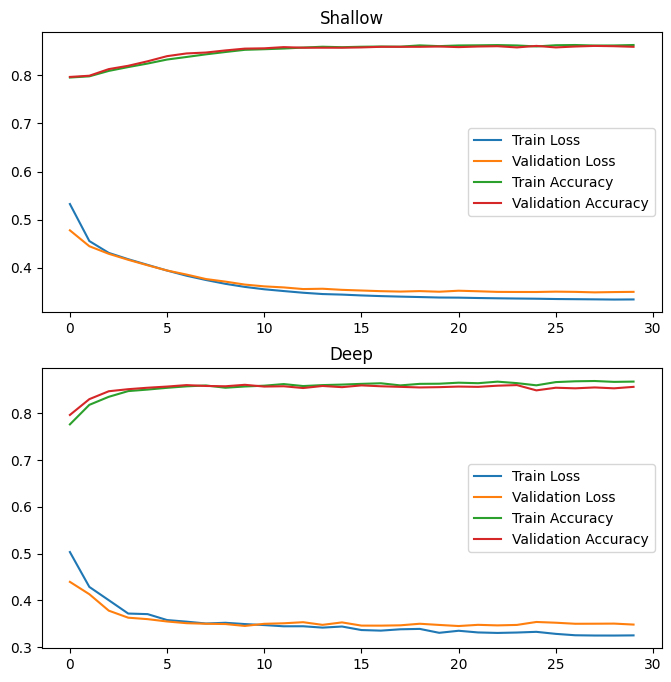

In [10]:
fig,ax=plt.subplots(2,1,figsize=(8,8))
for i,(h,t) in enumerate([(h1,"Shallow"),(h2,"Deep")]):
 ax[i].plot(h["tl"],label="Train Loss"); ax[i].plot(h["vl"],label="Validation Loss")
 ax[i].plot(h["ta"],label="Train Accuracy"); ax[i].plot(h["va"],label="Validation Accuracy")
 ax[i].set_title(t); ax[i].legend()
plt.show()

## 11. Confusion Matrix

This section performs the corresponding step in the neural network workflow.

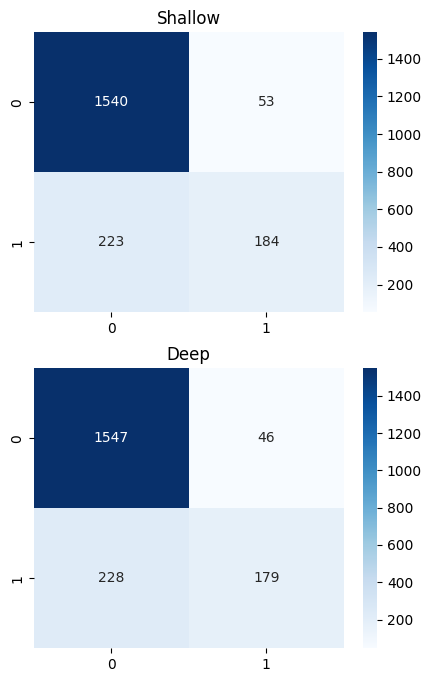

In [11]:
fig,ax=plt.subplots(2,1,figsize=(5,8))
for i,(pred,t) in enumerate([(p1,"Shallow"),(p2,"Deep")]):
 sns.heatmap(confusion_matrix(yte,pred),annot=True,fmt="d",cmap="Blues",ax=ax[i]); ax[i].set_title(t)
plt.show()

## 12. ROC and AUC

This section performs the corresponding step in the neural network workflow.

Shallow
              precision    recall  f1-score   support

           0       0.87      0.97      0.92      1593
           1       0.78      0.45      0.57       407

    accuracy                           0.86      2000
   macro avg       0.82      0.71      0.74      2000
weighted avg       0.85      0.86      0.85      2000

Deep
              precision    recall  f1-score   support

           0       0.87      0.97      0.92      1593
           1       0.80      0.44      0.57       407

    accuracy                           0.86      2000
   macro avg       0.83      0.71      0.74      2000
weighted avg       0.86      0.86      0.85      2000



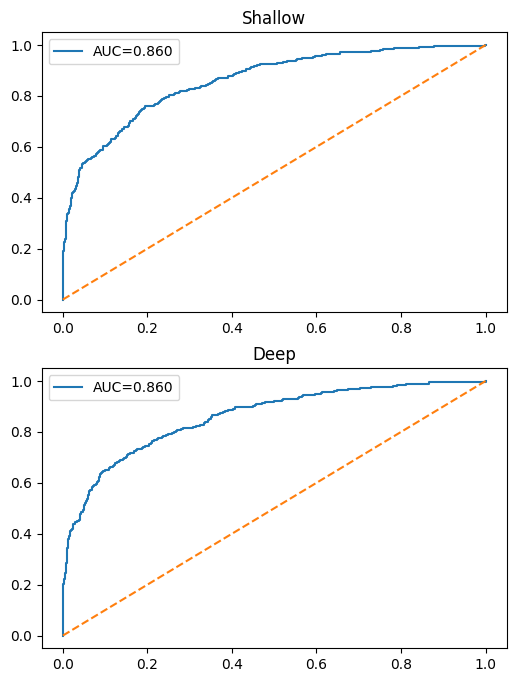

In [12]:
fig,ax=plt.subplots(2,1,figsize=(6,8)); vals=[]
for i,(prob,pred,t) in enumerate([(pr1,p1,"Shallow"),(pr2,p2,"Deep")]):
 fpr,tpr,_=roc_curve(yte,prob); A=auc(fpr,tpr)
 ax[i].plot(fpr,tpr,label=f"AUC={A:.3f}"); ax[i].plot([0,1],[0,1],"--"); ax[i].legend(); ax[i].set_title(t)
 print(t); print(classification_report(yte,pred))
 vals.append([accuracy_score(yte,pred),precision_score(yte,pred),recall_score(yte,pred),f1_score(yte,pred),A])
plt.show()

## 13. Metrics Comparison

This section performs the corresponding step in the neural network workflow.

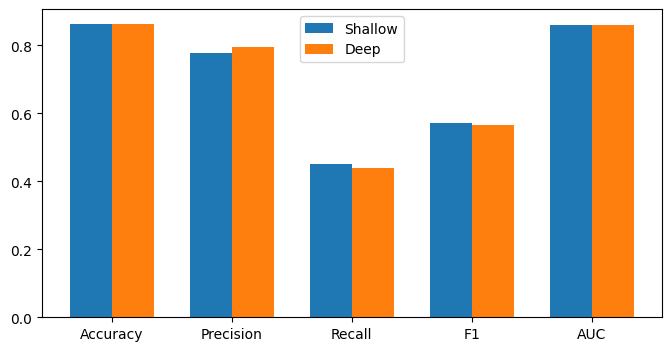

In [13]:
labels=["Accuracy","Precision","Recall","F1","AUC"]
x=np.arange(len(labels)); w=0.35
plt.figure(figsize=(8,4))
plt.bar(x-w/2,vals[0],w,label="Shallow")
plt.bar(x+w/2,vals[1],w,label="Deep")
plt.xticks(x,labels); plt.legend(); plt.show()

## 14. Network Structures

This section performs the corresponding step in the neural network workflow.

In [14]:
print(shallow)
print()
print(deep)

ShallowNN(
  (net): Sequential(
    (0): Linear(in_features=13, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=1, bias=True)
    (3): Sigmoid()
  )
)

DeepNN(
  (net): Sequential(
    (0): Linear(in_features=13, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=64, out_features=32, bias=True)
    (7): ReLU()
    (8): Linear(in_features=32, out_features=1, bias=True)
    (9): Sigmoid()
  )
)


## 15. Critical Analysis

The shallow neural network provides a strong baseline with fewer trainable parameters and lower computational complexity. The deep neural network is capable of learning more complex feature representations because it contains multiple hidden layers and dropout regularization. The evaluation metrics, ROC curve, and confusion matrices should be compared to determine whether the deeper architecture provides a meaningful improvement. If the training accuracy continues to increase while the validation accuracy stagnates or decreases, the deep model is likely experiencing overfitting. The final model selection should therefore consider both predictive performance and generalization capability.